In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Load dữ liệu
df = pd.read_csv('CC GENERAL.csv')
print(df.isnull().sum())
# 2. Xử lý giá trị thiếu (Missing Values)
# Cột MINIMUM_PAYMENTS thiếu nhiều, ta dùng Median để điền vào
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# 3. Bỏ cột ID vì không dùng để tính toán
X_raw = df.drop('CUST_ID', axis=1)


print(f"Dữ liệu đã sạch! Kích thước: {X_raw.shape}")

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Dữ liệu đã sạch! Kích thước: (8950, 17)


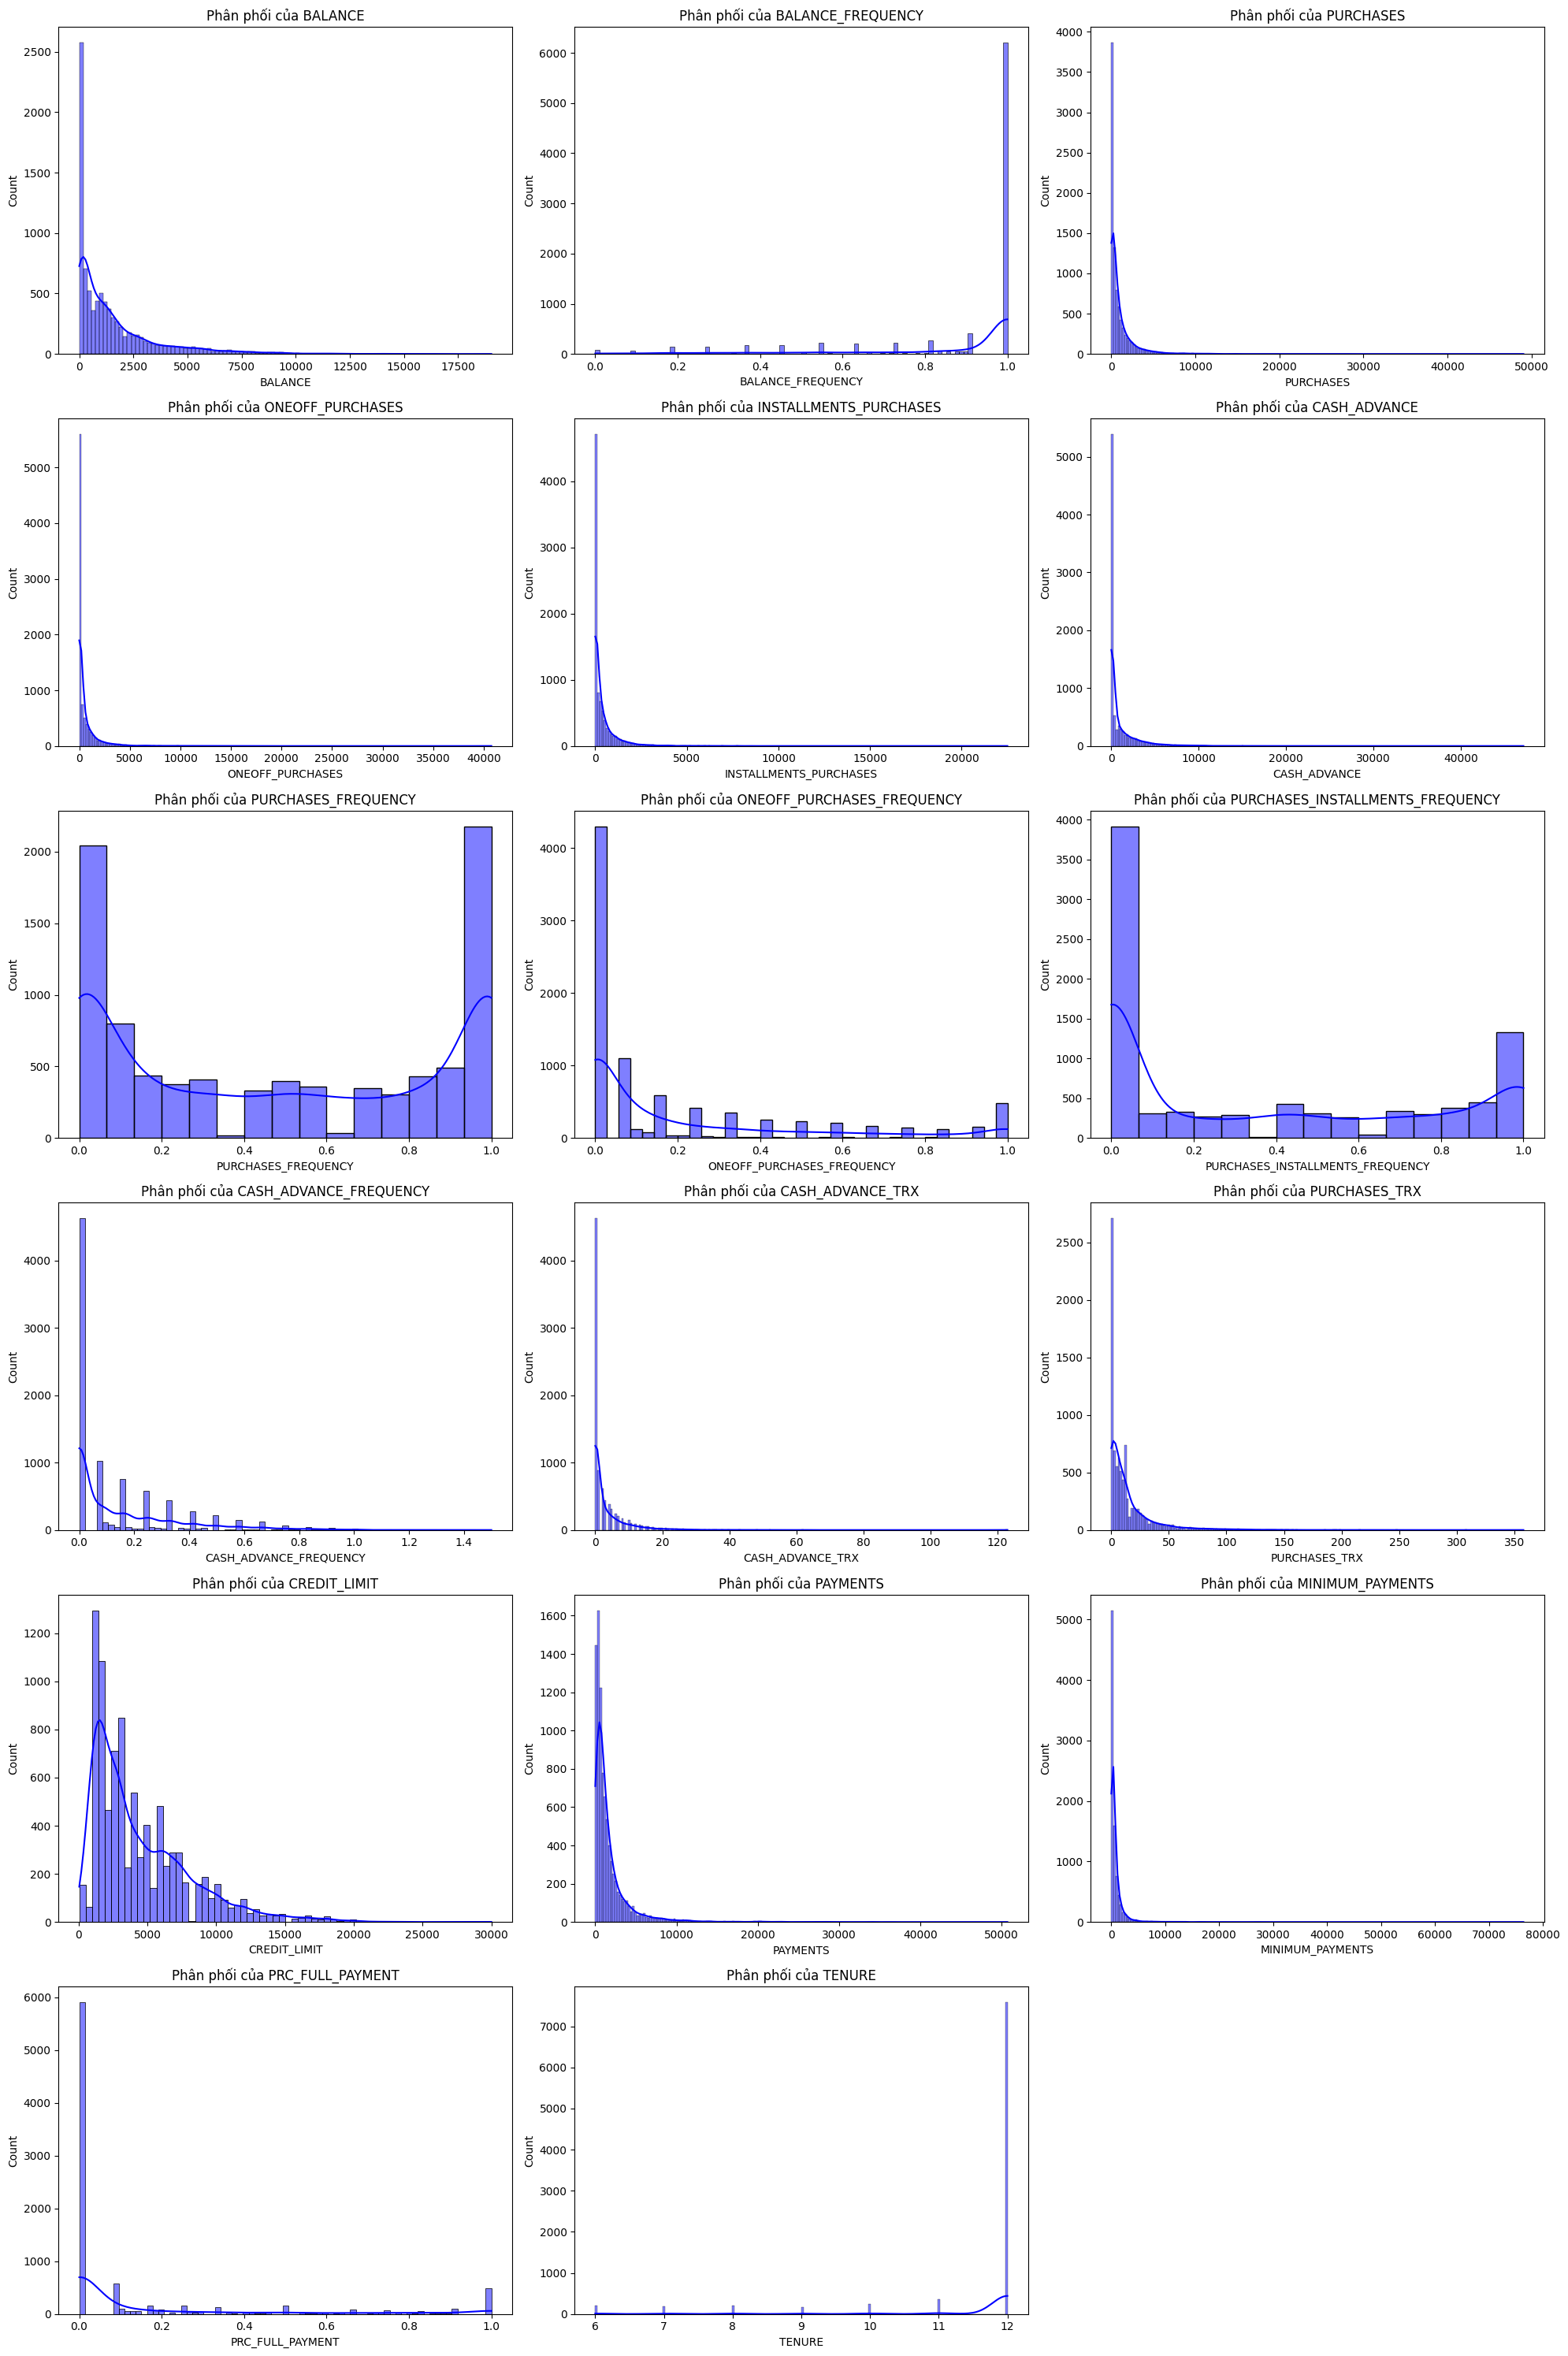

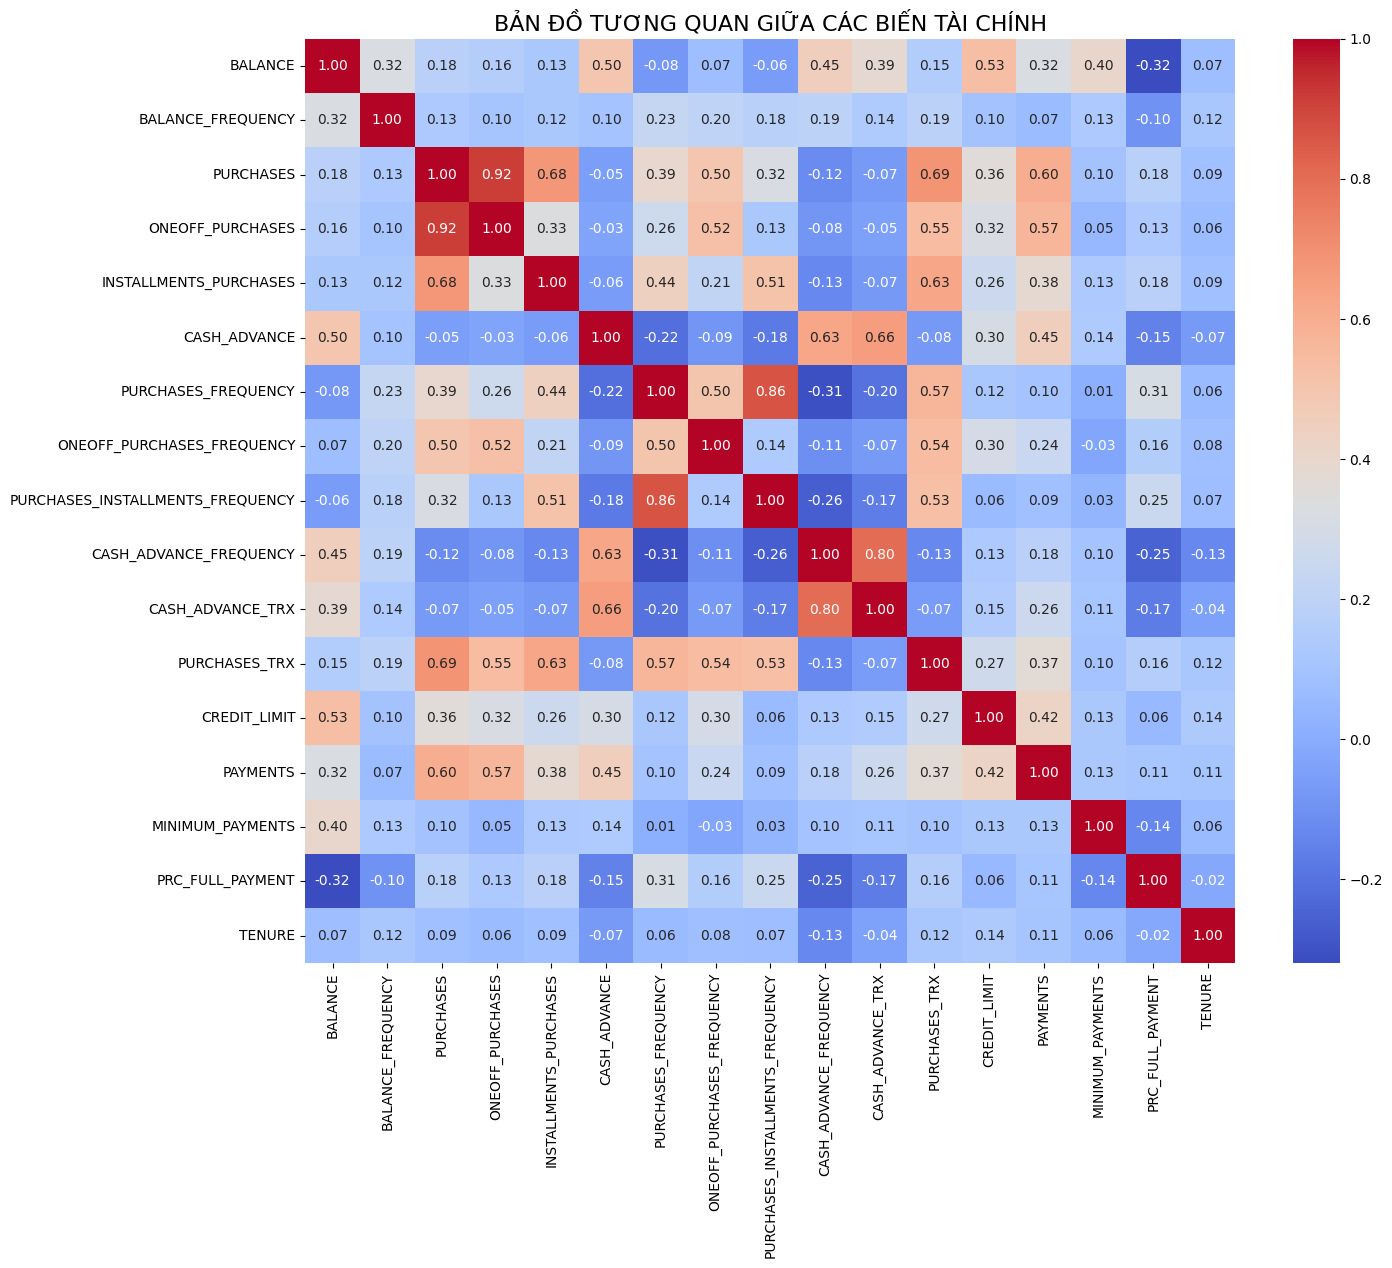

In [14]:
# Vẽ phân phối cho 17 biến để lấy tư liệu viết báo cáo (Chương 2)
features_to_plot = X_raw.columns
plt.figure(figsize=(20, 30))

for i, col in enumerate(features_to_plot):
    plt.subplot(6, 3, i+1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col}', fontsize=12)
    plt.tight_layout()

plt.savefig('all_distributions.png')
plt.show()

# Vẽ ma trận tương quan (Heatmap)
plt.figure(figsize=(15, 12))
sns.heatmap(X_raw.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('BẢN ĐỒ TƯƠNG QUAN GIỮA CÁC BIẾN TÀI CHÍNH', fontsize=16)
plt.savefig('correlation_heatmap.png')
plt.show()

In [20]:
# 1. Log Transformation: Giúp dữ liệu bớt lệch (skewed)
# Cộng 1 để tránh lỗi log(0)
X_log = np.log(1 + X_raw)

# 2. Chuẩn hóa về cùng thang đo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Đã log-transform và chuẩn hóa xong!")

Đã log-transform và chuẩn hóa xong!


In [21]:
# Nén 17 biến xuống còn 2 biến chính để dễ hình dung (Visualize)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame cho PCA để vẽ hình
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print(f"Đã nén 17 chiều xuống còn 2 chiều. Thông tin giữ lại: {pca.explained_variance_ratio_.sum():.2%}")

Đã nén 17 chiều xuống còn 2 chiều. Thông tin giữ lại: 56.46%


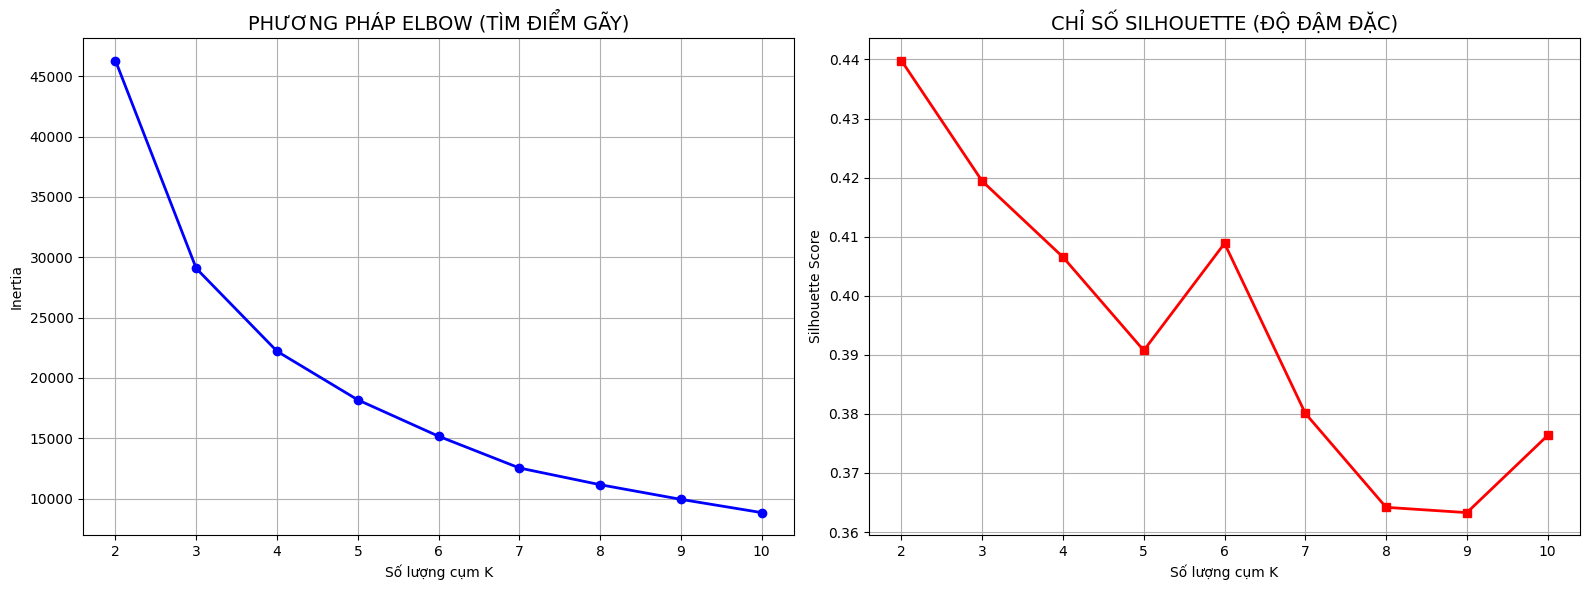

In [6]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 11) # Bắt đầu từ 2 cụm

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Vẽ đồ thị so sánh kép
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị Elbow
ax1.plot(K_range, inertias, marker='o', color='blue', linewidth=2)
ax1.set_title('PHƯƠNG PHÁP ELBOW (TÌM ĐIỂM GÃY)', fontsize=14)
ax1.set_xlabel('Số lượng cụm K')
ax1.set_ylabel('Inertia')
ax1.grid(True)
plt.savefig('elbow_plot.png', dpi=300, bbox_inches='tight')

# Đồ thị Silhouette
ax2.plot(K_range, sil_scores, marker='s', color='red', linewidth=2)
ax2.set_title('CHỈ SỐ SILHOUETTE (ĐỘ ĐẬM ĐẶC)', fontsize=14)
ax2.set_xlabel('Số lượng cụm K')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)
plt.savefig('silhouette_analysis.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

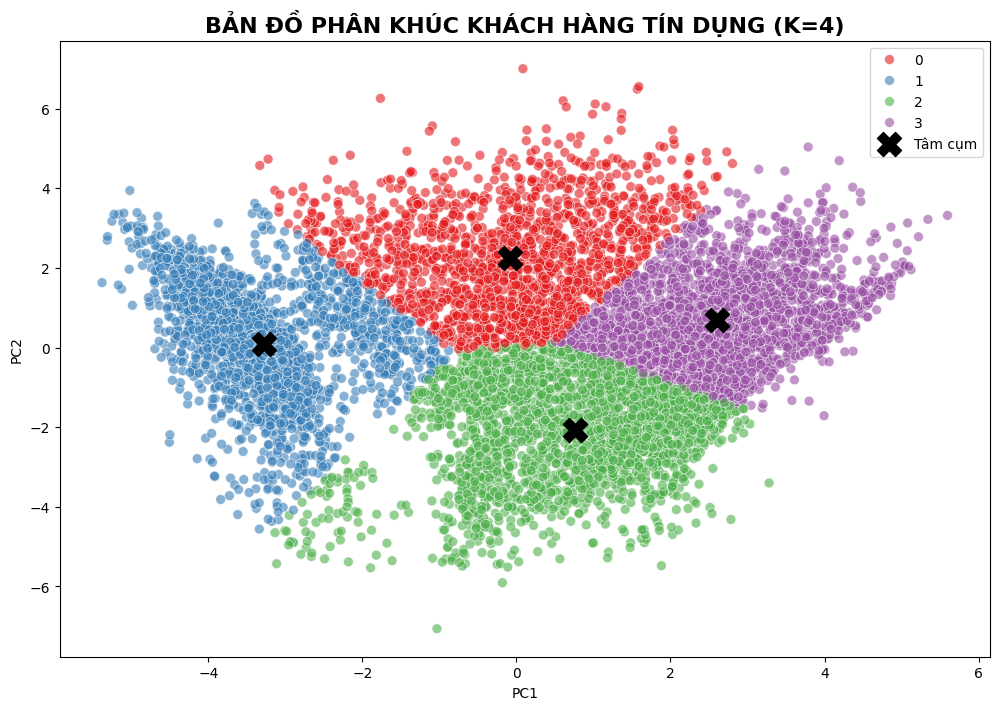

In [22]:
# Chú có thể sửa số 4 thành số chú thấy hợp lý nhất sau khi xem hình nhé
optimal_k = 4 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca) # Gán nhãn vào DF gốc
pca_df['Cluster'] = df['Cluster'] # Gán nhãn vào bảng PCA để vẽ

# Vẽ bản đồ 2D siêu đẹp
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=pca_df, 
    palette='Set1', 
    s=50, alpha=0.6, edgecolor='w'
)

# Đánh dấu tâm cụm (Centroids)
centroids_pca = kmeans.cluster_centers_
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    s=300, c='black', marker='X', label='Tâm cụm'
)

plt.title(f'BẢN ĐỒ PHÂN KHÚC KHÁCH HÀNG TÍN DỤNG (K={optimal_k})', fontsize=16, fontweight='bold')
plt.legend()
plt.savefig('pca_clusters.png', dpi=300, bbox_inches='tight')

plt.show()

BẢNG TÓM TẮT ĐẶC TRƯNG CỦA 4 CỤM KHÁCH HÀNG:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT
Cluster,,,,,,,,
0,3285.62,1297.60,2364.45,5895.22,2811.81,0.63,0.30,0.03
1,2154.68,29.53,1982.57,3985.62,1597.53,0.02,0.28,0.03
2,242.20,393.05,30.33,3122.18,641.99,0.49,0.01,0.24
3,1258.46,2494.06,55.06,5601.13,2358.80,0.89,0.01,0.26


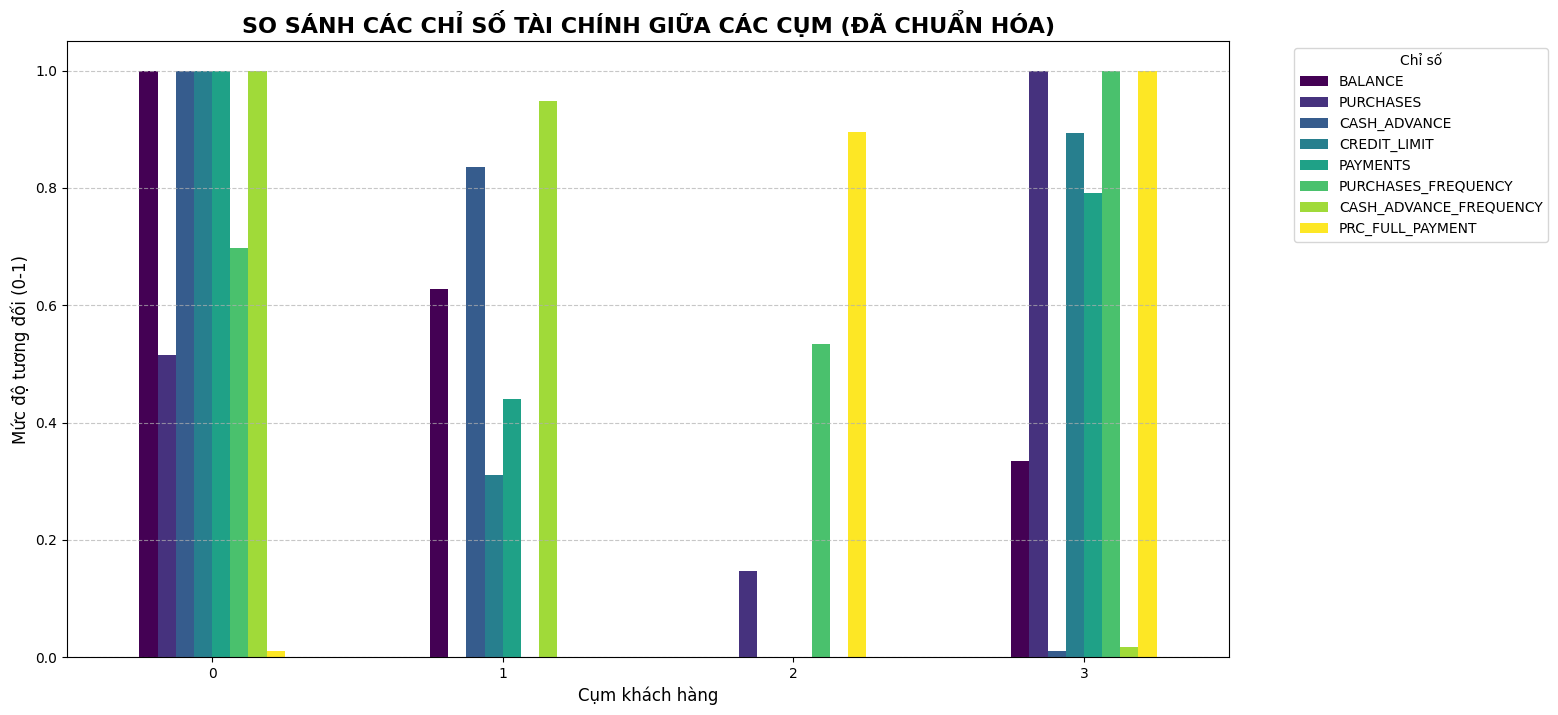

In [8]:
# 1. Tính giá trị trung bình của các thuộc tính gốc cho từng cụm
# Chúng ta dùng các cột gốc (chưa log, chưa scale) để con số có ý nghĩa thực tế (USD)
key_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
    'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY', 
    'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT'
]

cluster_summary = df.groupby('Cluster')[key_features].mean()

# 2. Hiển thị bảng kết quả (Copy bảng này vào Word)
print("BẢNG TÓM TẮT ĐẶC TRƯNG CỦA 4 CỤM KHÁCH HÀNG:")
display(cluster_summary.round(2))

# 3. Trực quan hóa bằng biểu đồ cột (Bar Chart)
# Chuẩn hóa nhẹ để vẽ các cột có đơn vị khác nhau (USD vs Tần suất) lên cùng một hình
from sklearn.preprocessing import MinMaxScaler
scaler_plot = MinMaxScaler()
cluster_summary_scaled = pd.DataFrame(
    scaler_plot.fit_transform(cluster_summary), 
    columns=cluster_summary.columns, 
    index=cluster_summary.index
)

cluster_summary_scaled.plot(kind='bar', figsize=(15, 8), colormap='viridis')
plt.title('SO SÁNH CÁC CHỈ SỐ TÀI CHÍNH GIỮA CÁC CỤM (ĐÃ CHUẨN HÓA)', fontsize=16, fontweight='bold')
plt.xlabel('Cụm khách hàng', fontsize=12)
plt.ylabel('Mức độ tương đối (0-1)', fontsize=12)
plt.legend(title='Chỉ số', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

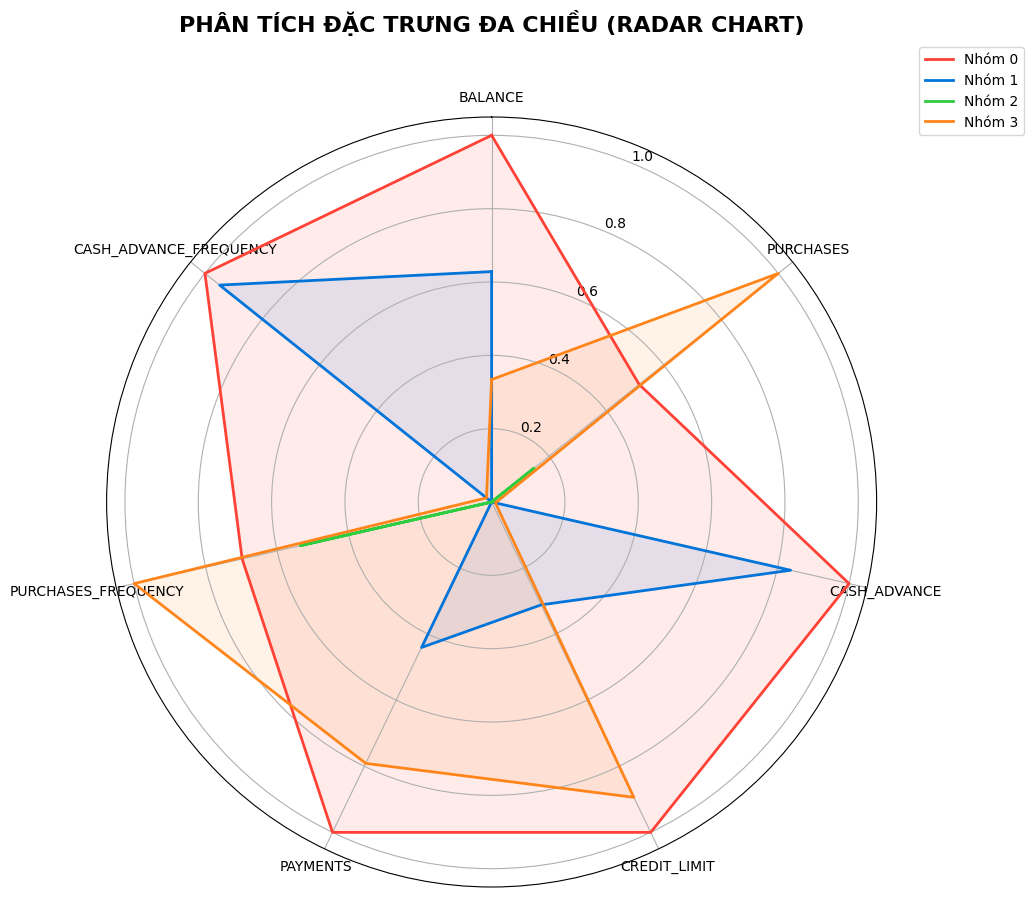

In [9]:
from sklearn.preprocessing import MinMaxScaler

# 1. Chọn ra các biến đặc trưng nhất để vẽ cho đỡ rối
radar_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 
                  'PAYMENTS', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

# 2. Tính trung bình và chuẩn hóa về [0, 1] để các vòng radar cân đối
cluster_stats = df.groupby('Cluster')[radar_features].mean()
scaler_radar = MinMaxScaler()
scaled_stats = pd.DataFrame(scaler_radar.fit_transform(cluster_summary[radar_features]), 
                            columns=radar_features, index=cluster_summary.index)

# 3. Hàm vẽ Radar Chart
def plot_radar_chart(stats_df):
    labels = stats_df.columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Đóng vòng

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    colors = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B'] # Đỏ, Xanh, Lục, Cam

    for i in range(len(stats_df)):
        values = stats_df.iloc[i].tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Nhóm {i}')
        ax.fill(angles, values, color=colors[i], alpha=0.1)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.title('PHÂN TÍCH ĐẶC TRƯNG ĐA CHIỀU (RADAR CHART)', y=1.1, fontsize=16, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

plot_radar_chart(scaled_stats)

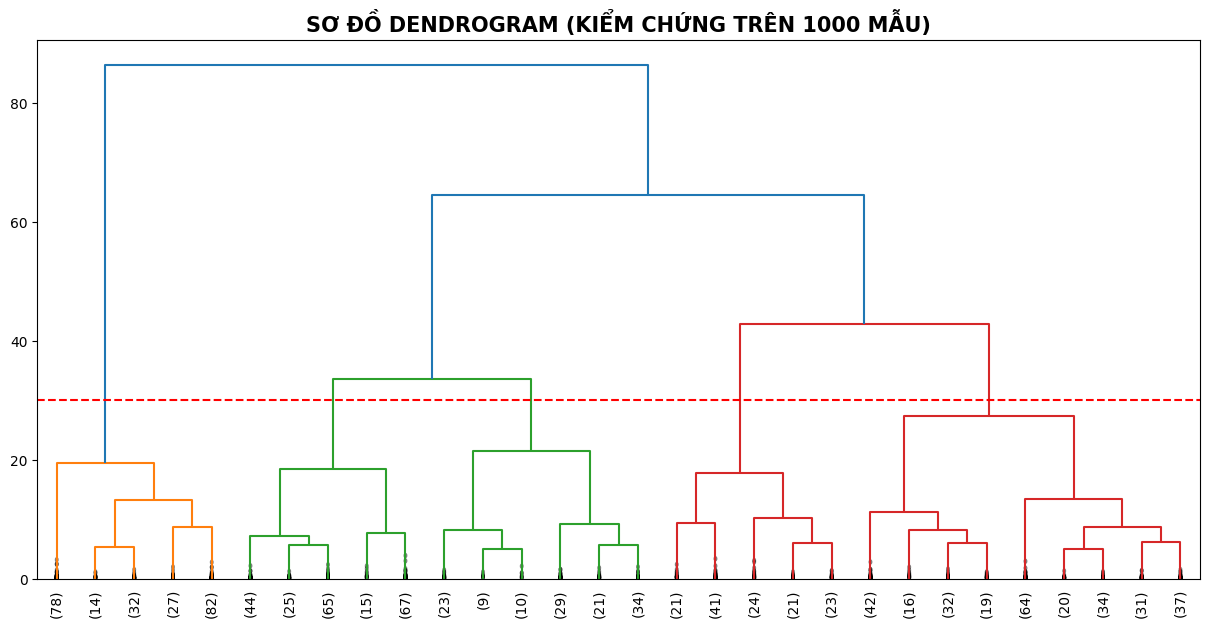

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Lấy mẫu 1000 dòng để vẽ Dendrogram cho nhanh và rõ (9000 dòng sẽ bị kín hình)
X_sample = X_pca[np.random.choice(X_pca.shape[0], 1000, replace=False)]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('SƠ ĐỒ DENDROGRAM (KIỂM CHỨNG TRÊN 1000 MẪU)', fontsize=15, fontweight='bold')
plt.axhline(y=30, color='r', linestyle='--') # Ngưỡng cắt
plt.show()

Số lượng khách hàng 'dị biệt' tìm thấy: 40


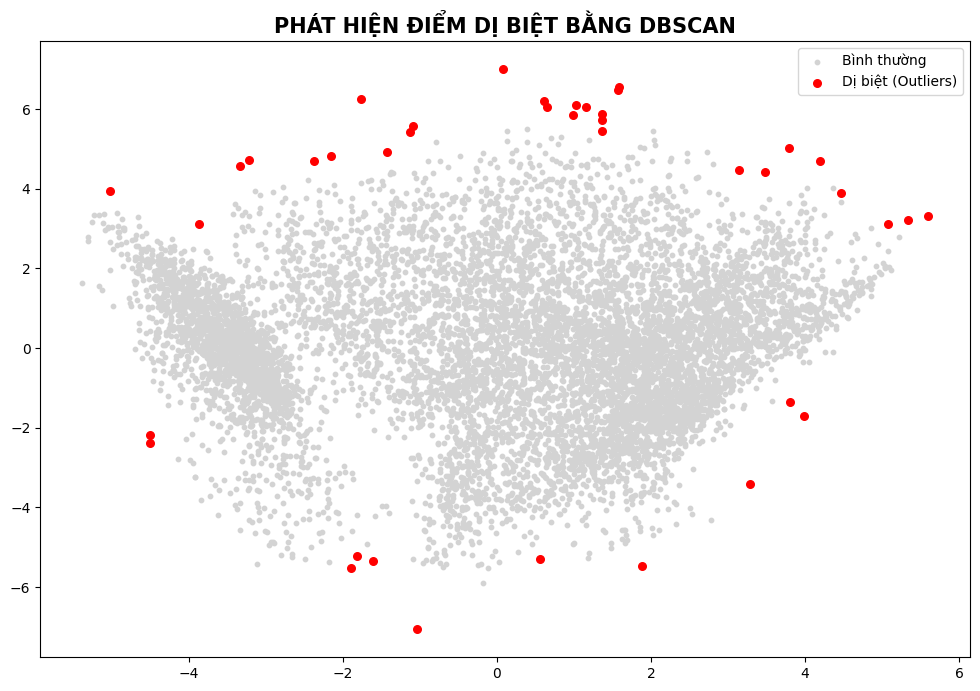

In [23]:
from sklearn.cluster import DBSCAN

# Chạy DBSCAN trên không gian PCA để tìm nhiễu
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)

df['Is_Outlier'] = (dbscan_labels == -1)
print(f"Số lượng khách hàng 'dị biệt' tìm thấy: {df['Is_Outlier'].sum()}")

# Vẽ hình các điểm nhiễu (màu đỏ) trên nền dữ liệu (màu xám)
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[dbscan_labels != -1, 0], X_pca[dbscan_labels != -1, 1], c='lightgrey', s=10, label='Bình thường')
plt.scatter(X_pca[dbscan_labels == -1, 0], X_pca[dbscan_labels == -1, 1], c='red', s=30, label='Dị biệt (Outliers)')
plt.title('PHÁT HIỆN ĐIỂM DỊ BIỆT BẰNG DBSCAN', fontsize=15, fontweight='bold')
plt.legend()
plt.show()

In [25]:
# Lưu kết quả ra file CSV mới
df.to_csv('Credit_Card_Clustered_Results.csv', index=False)
print("Đã xuất file 'Credit_Card_Clustered_Results.csv'!")

Đã xuất file 'Credit_Card_Clustered_Results.csv'!


In [24]:

# ===== TRÍCH XUẤT TẤT CẢ DỮ LIỆU THỰC TẾ CHO BÁO CÁO LATEX =====

print("="*80)
print("1. THÔNG TIN CỤM KHÁCH HÀNG")
print("="*80)

# Kích thước và tỷ lệ từng cụm
cluster_sizes = df['Cluster'].value_counts().sort_index()
print("\nKích thước cụm:")
for cluster_id in sorted(df['Cluster'].unique()):
    count = cluster_sizes[cluster_id]
    pct = 100 * count / len(df)
    print(f"  Cụm {cluster_id}: {count:,} khách ({pct:.1f}%)")

print("\n" + "="*80)
print("2. THỐNG KÊ CHỈ TIÊU CHÍNH THEO CỤM (GIÁ TRỊ THỰC)")
print("="*80)

key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
cluster_stats = df.groupby('Cluster')[key_cols].mean().round(2)
print("\nTrung bình các biến tài chính theo cụm:")
print(cluster_stats)

print("\n" + "="*80)
print("3. CENTROID TRONG KHÔNG GIAN PCA")
print("="*80)
print("\nTọa độ tâm cụm (PC1, PC2):")
for i, centroid in enumerate(kmeans.cluster_centers_):
    print(f"  Cụm {i}: PC1={centroid[0]:.4f}, PC2={centroid[1]:.4f}")

print("\n" + "="*80)
print("4. CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH")
print("="*80)

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(X_pca, df['Cluster'])
davies_bouldin = davies_bouldin_score(X_pca, df['Cluster'])
calinski_harabasz = calinski_harabasz_score(X_pca, df['Cluster'])

print(f"\nK-means (K={optimal_k}) trên không gian PCA:")
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz:.2f}")
print(f"  Inertia (cuối cùng): {kmeans.inertia_:.2f}")

print("\n" + "="*80)
print("5. PHÁT HIỆN OUTLIER (DBSCAN)")
print("="*80)

outlier_count = df['Is_Outlier'].sum()
outlier_pct = 100 * outlier_count / len(df)
print(f"\nSố lượng outlier phát hiện: {outlier_count} khách ({outlier_pct:.2f}%)")

if outlier_count > 0:
    outlier_stats = df[df['Is_Outlier']][key_cols].mean().round(2)
    print("\nThống kê outlier:")
    print(outlier_stats)

print("\n" + "="*80)
print("6. PHƯƠNG SAI GIẢI THÍCH (PCA)")
print("="*80)

# Tính PCA với tất cả thành phần để lấy thông tin
pca_full = PCA()
pca_full.fit(X_scaled)
print(f"\nPC1 giải thích: {pca_full.explained_variance_ratio_[0]:.2%}")
print(f"PC2 giải thích: {pca_full.explained_variance_ratio_[1]:.2%}")
print(f"PC1+PC2 tổng: {pca_full.explained_variance_ratio_[:2].sum():.2%}")

print("\n" + "="*80)
print("7. KÍCH THƯỚC DỮ LIỆU GỐC")
print("="*80)

print(f"\nSố hàng: {len(df):,}")
print(f"Số cột: {len(X_raw.columns)}")
print(f"Các cột: {', '.join(X_raw.columns)}")

print("\n" + "="*80)


1. THÔNG TIN CỤM KHÁCH HÀNG

Kích thước cụm:
  Cụm 0: 1,590 khách (17.8%)
  Cụm 1: 2,418 khách (27.0%)
  Cụm 2: 2,609 khách (29.2%)
  Cụm 3: 2,333 khách (26.1%)

2. THỐNG KÊ CHỈ TIÊU CHÍNH THEO CỤM (GIÁ TRỊ THỰC)

Trung bình các biến tài chính theo cụm:
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                             
0        3285.62    1297.60       2364.45       5895.22   2811.81   
1        2154.68      29.53       1982.57       3985.62   1597.53   
2         242.20     393.05         30.33       3122.18    641.99   
3        1258.46    2494.06         55.06       5601.13   2358.80   

         PRC_FULL_PAYMENT  TENURE  
Cluster                            
0                    0.03   11.59  
1                    0.03   11.33  
2                    0.24   11.34  
3                    0.26   11.86  

3. CENTROID TRONG KHÔNG GIAN PCA

Tọa độ tâm cụm (PC1, PC2):
  Cụm 0: PC1=-0.0781, PC2=2.2579
  Cụm 1: PC1=-3.2771